# Wakefield Simulation of SPS flanges with CPML boundary and TF/SF Injection

This notebooks shows how to use the new absorbing boundary condition CPML together with the improved injection scheme Total Fiald / Scatterd Field (TF/SF) on the simulation of one of the CERN-SPS vacuum flanges.

## Imports

In [ ]:
import numpy as np  # arrays and operations
import pyvista as pv  # for 3d plotting
import matplotlib.pyplot as plt  # for 1d, 2d plotting
from tqdm import tqdm

from wakis import GridFIT3D  # grid generation
from wakis import SolverFIT3D  # electromagnetic solver
from wakis import WakeSolver  # wakefield and impedance calculation
from wakis import geometry  # stp to stl import
from wakis.field_monitors import FieldMonitor

# For Github preview -- comment for interactive use
%matplotlib inline
pv.global_theme.window_size = [800, 400]
pv.set_jupyter_backend("static")
flag_plot_pyvista = True

# For jupyterlab use
# pv.global_theme.trame.server_proxy_enabled = True
# pv.global_theme.trame.server_proxy_prefix = '/proxy/'

## Build Geometry

In [2]:
pipe = pv.Cylinder(
    radius=41.5, height=300, direction=(0, 0, 1), center=(0, 0, 0)
).scale(1e-3)
cyl = pv.Cylinder(radius=78, height=100, direction=(0, 0, 1), center=(0, 0, 0)).scale(
    1e-3
)

trans = pipe.triangulate() | cyl.triangulate()
trans.save("SPS_400_pipe_trans_QF_B2_merged_m.stl")

stl_solids = {"transition": "SPS_400_pipe_trans_QF_B2_merged_m.stl"}
stl_materials = {"transition": "vacuum"}

2026-09-30 15:32:26.737 (  21.282s) [    7F99E025C740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


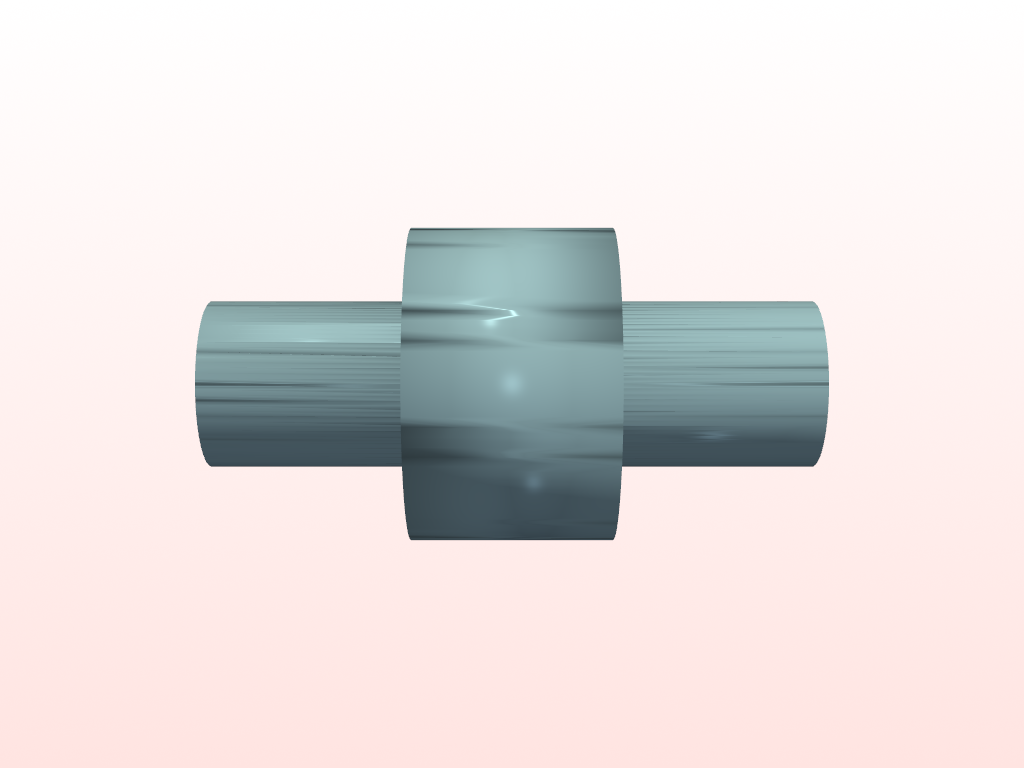

In [3]:
if flag_plot_pyvista:
    pl = pv.Plotter()
    pl.add_mesh(
        pv.read(stl_solids["transition"]),
        color="lightblue",
        specular=0.5,
        smooth_shading=True,
    )
    pl.set_background("mistyrose", top="white")
    pl.camera_position = "zx"
    pl.show()

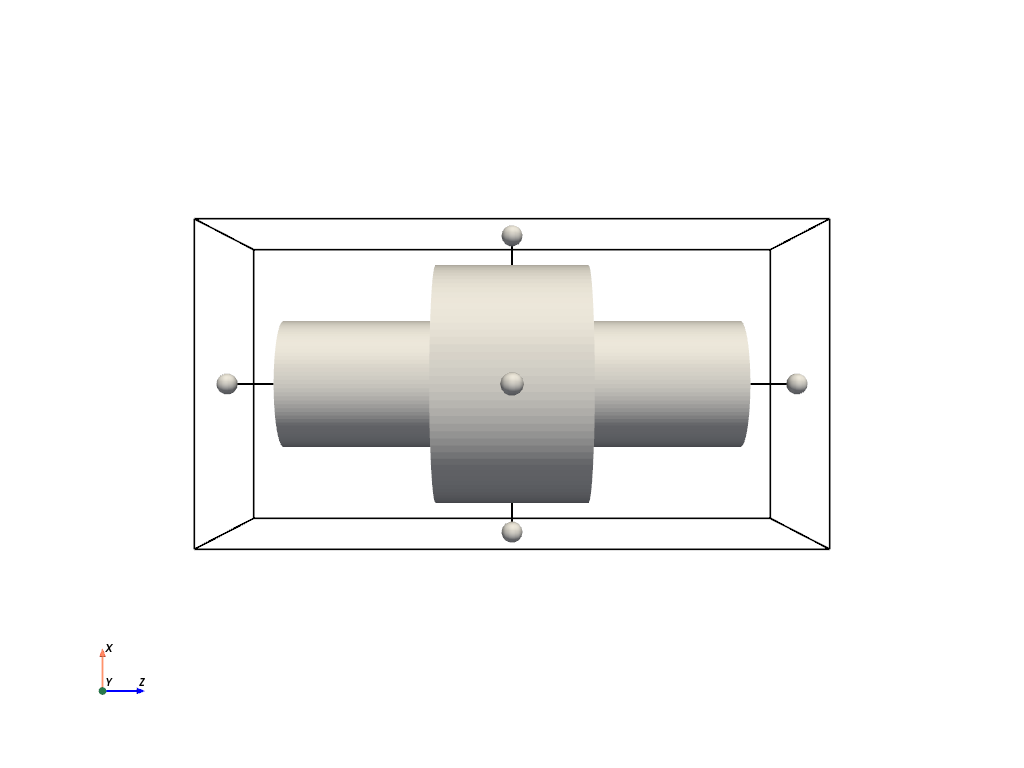

In [4]:
geometry = pv.read(stl_solids["transition"])

if flag_plot_pyvista:
    pl = pv.Plotter()
    pl.add_mesh_clip_box(geometry, color="white", rotation_enabled=False)
    pl.add_axes()
    pl.camera_position = "zx"
    pl.show()

## Grid Setup

Total number of cells: 3060300
Generating grid with 3060300 mesh cells...
    * Simulation domain bounds: 
                x:[-0.078, 0.078],
                y:[-0.078, 0.078],
                z:[-0.150, 0.150]
    * Minimum cell sizes: dx=1.545e-03, dy=1.545e-03, dz=1.000e-03
Importing STL solids...
 * Marking cells inside STL solid 'transition'...


Converting polydata: 100%|██████████[00:00<00:00]
Generating binary mask: 100%|██████████[00:00<00:00]

    * STL solid transition: 1246260 cells marked inside the solid.
Total grid initialization time: 0.5050711631774902 s


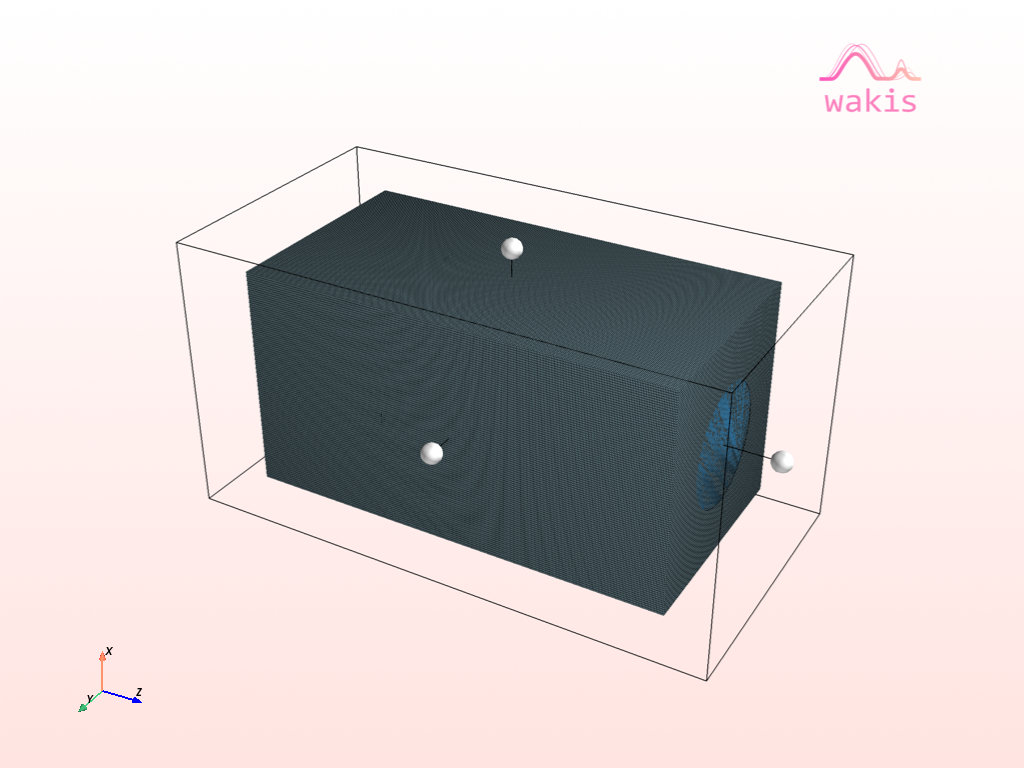

In [5]:
# Number of mesh cells
Nx = 101
Ny = 101
Nz = 300
print(f"Total number of cells: {Nx * Ny * Nz}")

xmin, xmax, ymin, ymax, zmin, zmax = geometry.bounds
# set grid and geometry
grid = GridFIT3D(
    xmin,
    xmax,
    ymin,
    ymax,
    zmin,
    zmax,
    Nx,
    Ny,
    Nz,
    stl_solids=stl_solids,
    stl_materials=stl_materials,
    stl_method="voxelize_rectilinear",
)

if flag_plot_pyvista:
    grid.inspect()

## Beam and Wake

Using CPML as boundary condition, the TF/SF injection is automatically set as injection scheme. Therefore the cells involved in the TF/SF injection need to be skipped as well and therefore the skip_cell should be n_cpml + 3.

In [6]:
# ------------ Beam source ----------------
# Beam parameters
sigmaz = 15e-3  # [m] -> f_max = beta*c/3sigmaz
q = 1e-9  # [C]
beta = 1.0  # beam beta
xs = 0.005  # x source position [m]
ys = 0.0  # y source position [m]
xt = 0.0  # x test position [m]
yt = 0.0  # y test position [m]
# [DEFAULT] tinj = 8.53*sigmaz/c_light  # injection time offset [s]

# Simualtion
wakelength = 5.0  # [m]
n_pml = 4
skip_cells = n_pml + 3
results_folder = f"001e_results/"
wake = WakeSolver(
    q=q,
    sigmaz=sigmaz,
    beta=beta,
    xsource=xs,
    ysource=ys,
    xtest=xt,
    ytest=yt,
    results_folder=results_folder,
    skip_cells=skip_cells,
    Ez_file=results_folder + "Ez.h5",
)

Initializing Wakefield parameters...
Total solver initialization time: 0.007941484451293945 s


## Solver

You can tune the CPML with the parameters in the solver. There are the parameters *alpha_max*, *kappa_max* and *sigma_factor* that influence the maximal values of the parameters. The *pml_exp* decides on the profile of the parameters. With *n_pml* you can choose the number of CPML layers that decide the level of reflection.

In [7]:
# boundary conditions
bc_low = ["pec", "pec", "cpml"]
bc_high = ["pec", "pec", "cpml"]

solver = SolverFIT3D(
    grid,
    wake,
    bc_low=bc_low,
    bc_high=bc_high,
    use_stl=True,
    bg="pec",  # background material
    use_gpu=False,
    verbose=2,
    n_pml=n_pml,
    alpha_max=0.1,
    kappa_max=10.0,
    pml_exp=4,
    sigma_factor=1.0,
)

Initializing Electromagnetic solver...
    * Maximum frequency set to fmax=6.6620546222222226 GHz
Assembling operator matrices...
Applying boundary conditions...
Adding material tensors...
    * Max resolved conductivity without SIBC: 190.1087227382346 S/m
Filling CPML parameters...
[!] CPML requires Total-Field/Scattered-Field injection, setting source_type='tfsf'
    * CPML thickness: 4 cells
Calculating maximal stable timestep...
    * Simulation timestep: dt=1.230e-12 s
    * Total simulation time for wakelength=1.0 m: tmax=4.761e-09 s
    * Total number of timesteps for wakelength=1.0 m: Nt=3870
Pre-computing...
Moving to GPU...
Total solver initialization time: 6.642014026641846 s


The sigma is not changing in the CPML because the CPML sigma is not the physical sigma but purely mathematical and inside the boundaries.

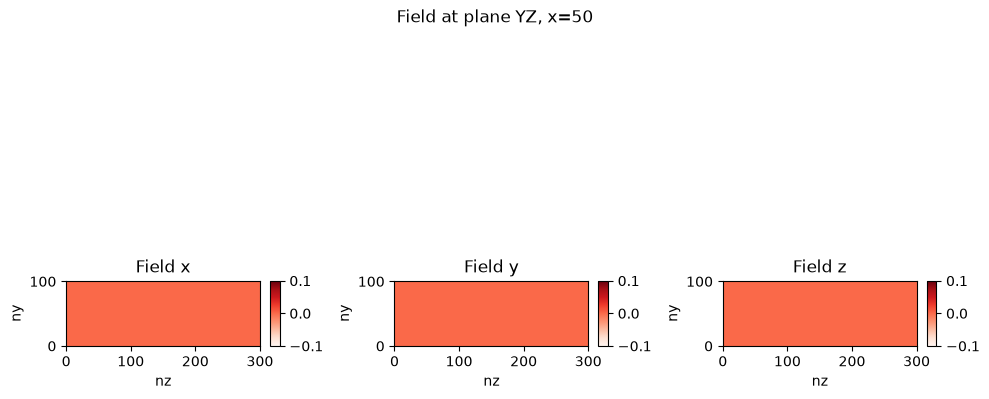

In [8]:
solver.sigma.inspect(
    plane="YZ",
)

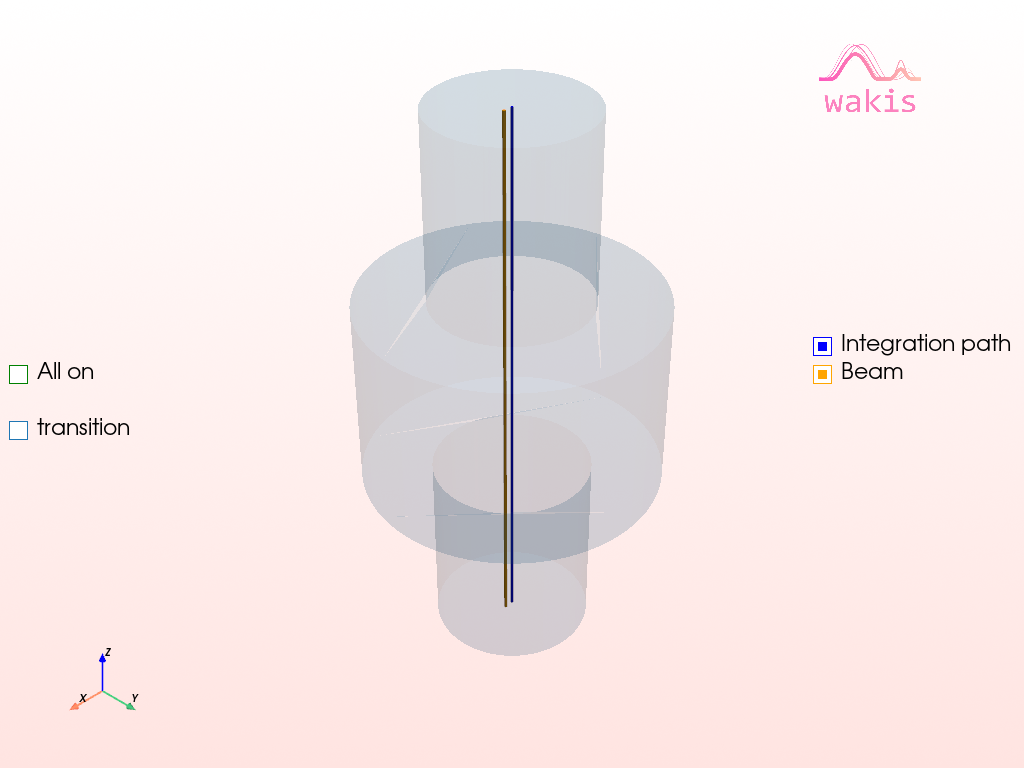

In [9]:
pl = solver.inspect(
    wake=wake,
    opacity=1.0,
    add_silhouette=True,
    off_screen=False,
    specular=0.0,
    smooth_shading=False,
)

## Run Simulation

In [10]:
solver.wakesolve(
    wakelength=wakelength,
    wake=wake,
    plot=False,
    plot_func=solver.plot1D,
    plot_every=100,
    plot_until=10000,
)

Running electromagnetic time-domain simulation...


  0%|          | 0/14717 [00:00<?, ?it/s]

[!] Total-Field/Scattered-Field injection started at t=0.000e+00s, Jmax=3.342e+06 Cm/s
Starting time-stepping with CPML...


  9%|▉         | 1359/14717 [00:41<04:18, 51.60it/s]

[!] Total-Field/Scattered-Field injection done at t=1.658e-09s, switching to regular field updates


...

Reading h5 file 001e_results/Ez.h5
Size of the h5 file: 0.32 Gb
Calculating longitudinal wake potential WP(s)


100%|██████████| 125163/125163 [01:23<00:00, 1494.81it/s]


Elapsed time 83.73260259628296 s
Calculating transverse wake potential WPx, WPy...


100%|██████████| 125163/125163 [00:01<00:00, 81372.84it/s]


Elapsed time 1.5398402214050293 s
Calculating longitudinal impedance Z...
[!] Using analytic charge distribution λ(s) since no data was provided
Calculating transverse impedance Zx, Zy...
Calculation terminated in 90s


## Plot Results

<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_520/2285249530.py:13: SyntaxWarning: invalid escape sequence '\O'
  ax[1].set_ylabel('Longitudinal impedance [Abs][$\Omega$]', color='tab:blue')


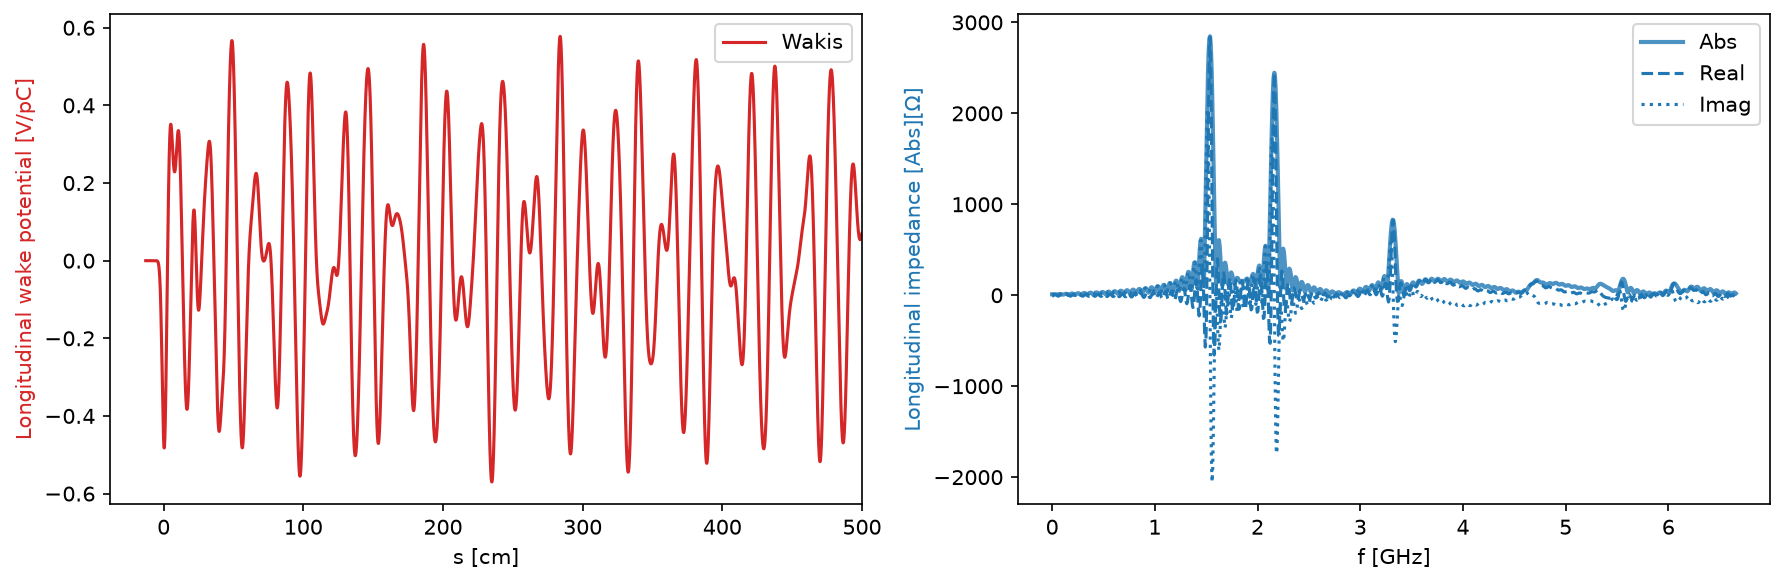

In [11]:
# Plot longitudinal wake potential and impedance
fig1, ax = plt.subplots(1, 2, figsize=[12, 4], dpi=150)
ax[0].plot(wake.s * 1e2, wake.WP, c="tab:red", lw=1.5, label="Wakis")
ax[0].set_xlabel("s [cm]")
ax[0].set_ylabel("Longitudinal wake potential [V/pC]", color="tab:red")
ax[0].legend()
ax[0].set_xlim(xmax=wakelength * 1e2)

ax[1].plot(wake.f * 1e-9, np.abs(wake.Z), c="tab:blue", alpha=0.8, lw=2, label="Abs")
ax[1].plot(wake.f * 1e-9, np.real(wake.Z), ls="--", c="tab:blue", lw=1.5, label="Real")
ax[1].plot(wake.f * 1e-9, np.imag(wake.Z), ls=":", c="tab:blue", lw=1.5, label="Imag")
ax[1].set_xlabel("f [GHz]")
ax[1].set_ylabel("Longitudinal impedance [Abs][$\Omega$]", color="tab:blue")
ax[1].legend()

fig1.tight_layout()
fig1.savefig(results_folder + "longitudinal.png")
plt.show()

The peak at 2.17 GHz in the transverse plane is parasitic and can be reduced with a higher grid resolution in x-direction.

<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_520/1256531106.py:13: SyntaxWarning: invalid escape sequence '\O'
  ax[1].set_ylabel('Transverse impedance X [Abs][$\Omega$]', color='tab:green')


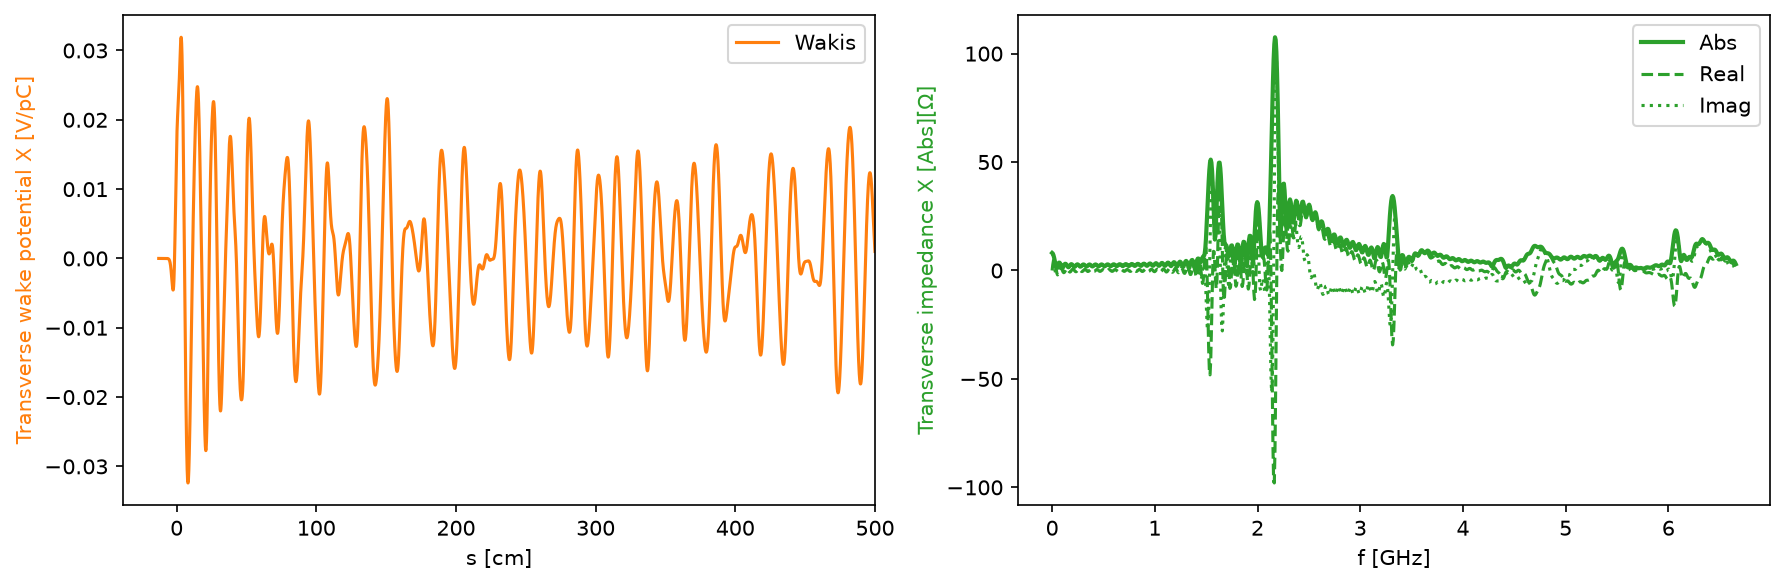

In [12]:
# Plot transverse x wake potential and impedance
fig2, ax = plt.subplots(1, 2, figsize=[12, 4], dpi=150)
ax[0].plot(wake.s * 1e2, wake.WPx, c="tab:orange", lw=1.5, label="Wakis")
ax[0].set_xlabel("s [cm]")
ax[0].set_ylabel("Transverse wake potential X [V/pC]", color="tab:orange")
ax[0].legend()
ax[0].set_xlim(xmax=wakelength * 1e2)

ax[1].plot(wake.fx * 1e-9, np.abs(wake.Zx), c="tab:green", lw=2, label="Abs")
ax[1].plot(
    wake.fx * 1e-9, np.real(wake.Zx), c="tab:green", ls="--", lw=1.5, label="Real"
)
ax[1].plot(
    wake.fx * 1e-9, np.imag(wake.Zx), c="tab:green", ls=":", lw=1.5, label="Imag"
)
ax[1].set_xlabel("f [GHz]")
ax[1].set_ylabel("Transverse impedance X [Abs][$\Omega$]", color="tab:green")
ax[1].legend()

fig2.tight_layout()
fig2.savefig(results_folder + "001_transverse_x.png")
plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_520/2594157474.py:13: SyntaxWarning: invalid escape sequence '\O'
  ax[1].set_ylabel('Transverse impedance Y [Abs][$\Omega$]', color='tab:pink')


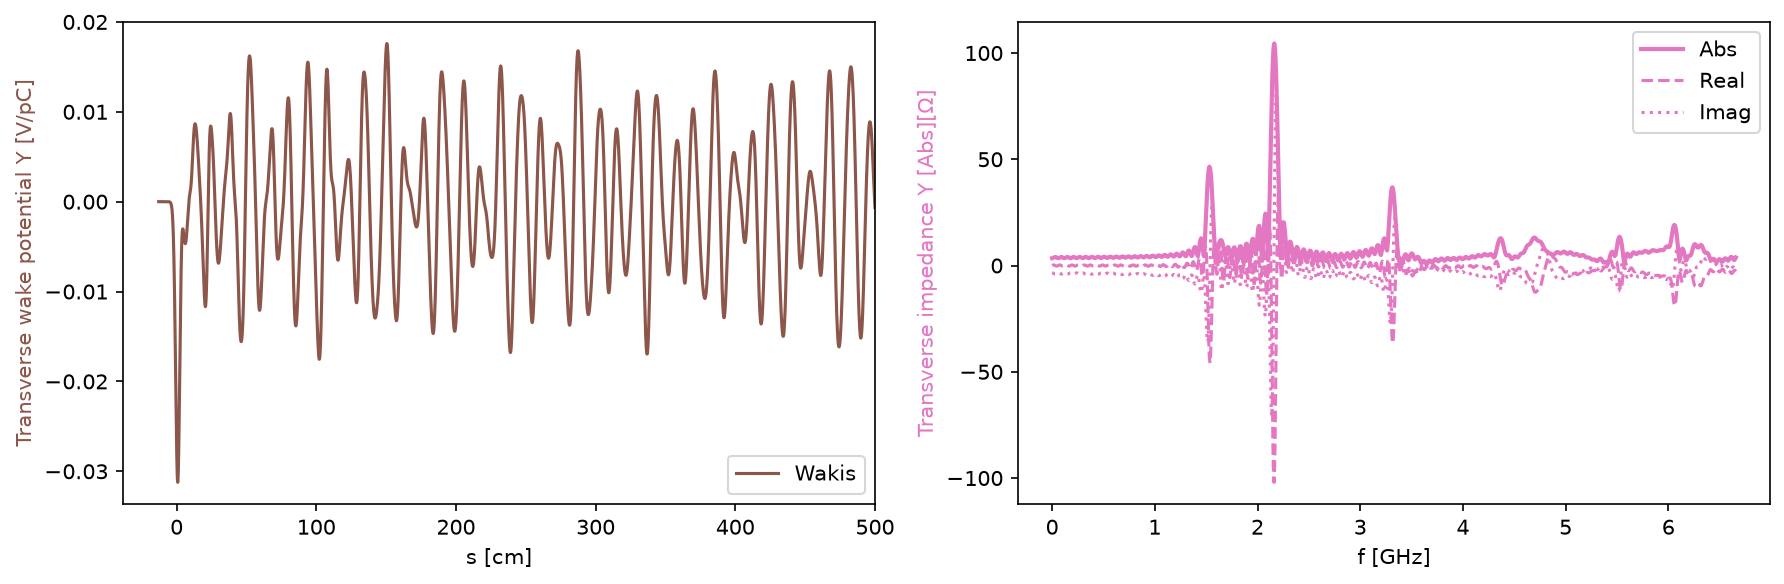

In [13]:
# Plot transverse y wake potential and impedance
fig3, ax = plt.subplots(1, 2, figsize=[12, 4], dpi=150)
ax[0].plot(wake.s * 1e2, wake.WPy, c="tab:brown", lw=1.5, label="Wakis")
ax[0].set_xlabel("s [cm]")
ax[0].set_ylabel("Transverse wake potential Y [V/pC]", color="tab:brown")
ax[0].legend()
ax[0].set_xlim(xmax=wakelength * 1e2)

ax[1].plot(wake.fy * 1e-9, np.abs(wake.Zy), c="tab:pink", lw=2, label="Abs")
ax[1].plot(
    wake.fy * 1e-9, np.real(wake.Zy), c="tab:pink", ls="--", lw=1.5, label="Real"
)
ax[1].plot(wake.fy * 1e-9, np.imag(wake.Zy), c="tab:pink", ls=":", lw=1.5, label="Imag")
ax[1].set_xlabel("f [GHz]")
ax[1].set_ylabel("Transverse impedance Y [Abs][$\Omega$]", color="tab:pink")
ax[1].legend()

fig3.tight_layout()
fig3.savefig(results_folder + "transverse_y.png")
plt.show()